In [209]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
colors_array = sns.color_palette("tab20")

In [214]:
# Define function for plotting residuals
def plot_residuals(x, fitted_model, training_observations=None, xlabel='', n_bins=20):
    plt.scatter(x, fitted_model.resid)
    plt.ylabel("Residuals")
    plt.xlabel(xlabel)
    plt.hlines(0.0,min(x),max(x),linestyles="dashed",color="red")

    if training_observations is not None:
        if xlabel == "Fitted values":
            residual_df = pd.DataFrame({"x": np.asarray(x), "residuals": np.asarray(fitted_model.resid)})
            residual_df["bin"] = pd.cut(residual_df["x"],bins=n_bins)
            mean_residuals = residual_df.groupby("bin", observed=True).agg(x=("x", "mean"),residuals=("residuals", "mean"))
            plt.plot(mean_residuals["x"],mean_residuals["residuals"],linestyle="-",color="yellow")
        else:
            residual_df = training_observations.copy()
            residual_df["residuals"] = np.asarray(fitted_model.resid)
            mean_residuals = (residual_df.groupby(xlabel)["residuals"] .mean().sort_index())
            plt.plot( mean_residuals.index,mean_residuals.values,linestyle="-",color="yellow")

    plt.show()


# Define function to get all residual plots at once
def get_residuals_plots(training_observations, model_object, parameters):
    plot_residuals(model_object.resid.index,model_object,xlabel="Index")
    plot_residuals(model_object.fittedvalues,model_object,xlabel="Fitted values", training_observations=training_observations)
    for parameter in parameters:
        plot_residuals(training_observations[parameter],model_object,xlabel=parameter,training_observations=training_observations)

# Define function for plotting mean residuals of one parameter over multiple values of another one
def plot_mean_residuals(training_observations, model_object, x_variable, sweeping_variable,legend=True):
    X_temp = training_observations.copy()
    X_temp['residuals'] = model_object.resid
    averaged_df = X_temp.groupby([x_variable, sweeping_variable])['residuals'].mean().reset_index()

    for j in sorted(averaged_df[sweeping_variable].unique()):
        subset = averaged_df[averaged_df[sweeping_variable] == j]
        plt.plot(subset[x_variable], subset['residuals'],marker='o', label=f"{sweeping_variable}: {j}")

    plt.axhline(0, color='red',linestyle='--')   # optional: zero-residual reference
    plt.ylabel("Mean residuals")
    plt.xlabel(x_variable)
    plt.grid()
    if legend:
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

In [159]:
# Load airfoil data
df = pd.read_csv("../data/airfoil_data.csv")

# Take only converged cases
df_model = df[df['converged']].copy()

In [160]:
# Define predictors and response
X = df_model[['m','p','t_c']]
y = df_model['CL']

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Add intercept to the X matrix
X_train = sm.add_constant(X_train)

In [161]:
# Show the correlation matrix
X_train.corr()

,const,m,p,t_c
const,NaN,NaN,NaN,NaN
m,NaN,1.000000,0.103136,0.019990
p,NaN,0.103136,1.000000,0.132773
t_c,NaN,0.019990,0.132773,1.000000


* The correlation matrix of predictors in the training set basically asks : “After removing non-converged geometries and taking the train split, have the predictors become linearly associated with each other?”
* Values of 0.3-0.5 would start to suggest that the answer is yes
* But correlation matrix can miss multicollinearity of combinations of multiple predictors
* Pairwise correlation only sees linear relationships between two variables at a time. It can miss nonlinear dependence and situations where one predictor is well explained by a combination of several others.
* AI summary: Pairwise correlations between \(m\), \(p\), and \(t/c\) are all weak (\(|r|<0.15\)). Therefore, there is no evidence of strong pairwise linear dependence among the predictors in the training data. However, pairwise correlation does not rule out multicollinearity involving combinations of predictors, so VIF should be checked next.

In [162]:
# Calculate Variance Inflation Factor (VIF)
vif_X = pd.DataFrame({"variable": X_train.columns,
    "VIF": [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]})
print(vif_X)

  variable       VIF
0    const  1.000000
1        m  1.010793
2        p  1.028520
3      t_c  1.017987


Notes:
- VIF calculates how well is parameter predicted by regression of all the other predictors
- If VIF=1 then the parameter has no linear relationship with the other parameters
- The more above 1 the VIF is, the larger it suggests collinearity with the other parameters
- Values 5-10 indicate stronger possible collinearity and values above 10 are usually considered serious
- In this case, the VIF values do not suggest any collinearity

In [163]:
# Specify the type of regression (least squares) and fit the model
model = sm.OLS(y_train,X_train).fit()
print(model.summary())

# Define list of all included parameters
parameters_list = ['m','p','t_c']

                            OLS Regression Results                            
Dep. Variable:                     CL   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     6548.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:00:25   Log-Likelihood:                 1794.8
No. Observations:                1869   AIC:                            -3582.
Df Residuals:                    1865   BIC:                            -3559.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4219      0.007     56.868      0.0

Observations:
* Large F-statistic → The full model explains substantially more variation in \(C_L\) than an intercept-only model, suggesting that at least one predictor is associated with \(C_L\).
* Prob(F) ≈ 0 → If all slope coefficients were truly zero, observing an F-statistic this large would be extremely unlikely. So we reject that null hypothesis.
* \(R^2 = 0.913\) → The model explains about 91.3% of the variation in \(C_L\) within the training data.
* All three predictors have p-value of ~0, which suggests that when holding the other two predictors currently included in the model constant, it would be extremely unlikely to observe coefficient estimates this extreme relative to their standard errors just by chance, if the coefficient was actually zero. We must however be careful about the possible interactions.
* Since we have a lot of observations (n=1869), the standard error SE is very small, since the coefficient is estimated very precisly.
    * Since t=beta estimate/SE, small SE can produce large t-statistic
    * The p-value says if there is a strong evidence that the coefficient is not zero, it does not say how big influence the coefficient actually has!!
    * The fact that all 3 p-values are small also doesnt mean there are not some important coefficients missing! Like additional linear terms, non-linear terms or interactions
* Standard errors are very small compared to the values of the coefficients
* Interpreting the physical meaning of the coefficients would be premature, considering the possible interactions indicated in EDA
* The negative coefficient of thickness suggest that linear fit might not be optimal, since lift doesn't immediately decrease with thickness

## Residual diagnostics

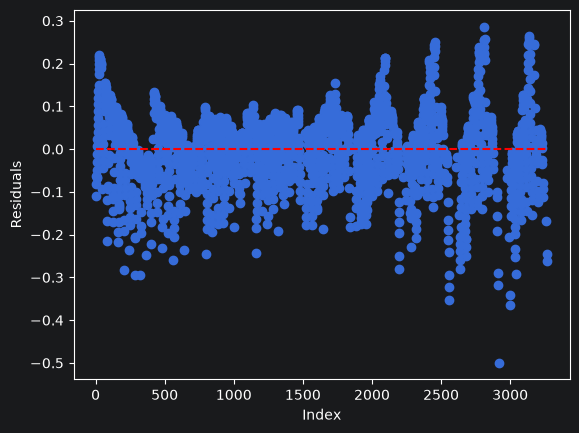

In [164]:
plot_residuals(model.resid.index,model,xlabel="Index")

Observations:
- Residuals strongly vary over the observation index
- There are clusters of observations with large residuals
- The clusters are probably cause by the ordering of the observations

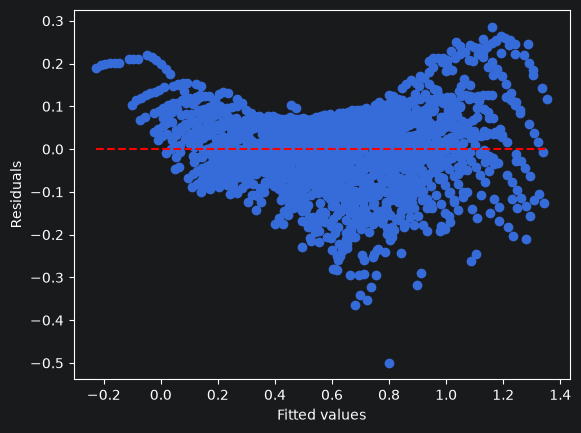

In [165]:
# Plot residuals against fitted values
plot_residuals(model.fittedvalues, model, xlabel="Fitted values")

Observations:
- Strong U-shaped structure is visible in the residuals, suggesting the pure linear model does not fully capture the underlying influences and systematically over- under-estimates the resulting value
- Several large residuals are present
- The line structures are likely result of the underlying measurements grid in the predictors
- The plot also shows signs of heteroscedasticity
    - The residuals are spreading more with the larger fitted value
    - This would suggest that the error variance is not constant but increases with fitted value
    - That would be a problem since the conventional formulas for standard error assume that the error variance is constant
    - But this should be addressed only if the spreading is present even after more suitable model is fit

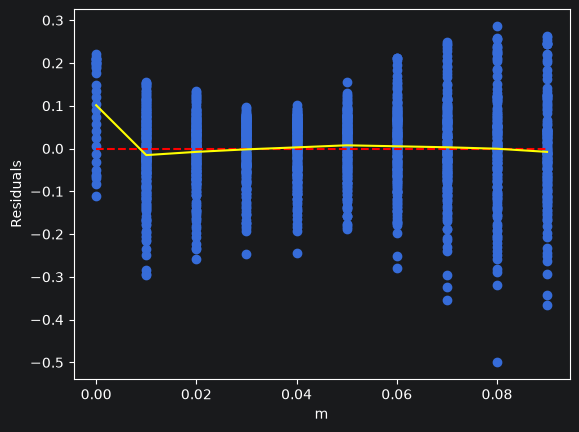

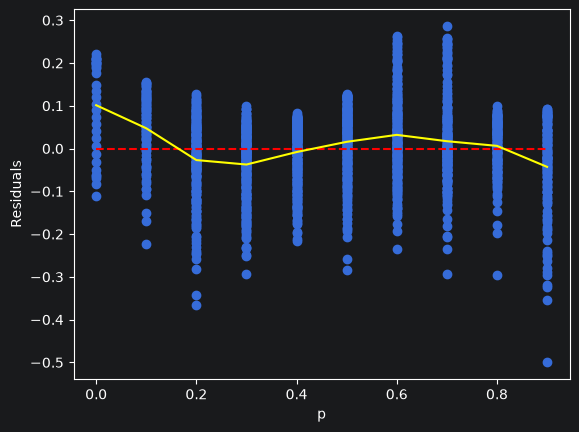

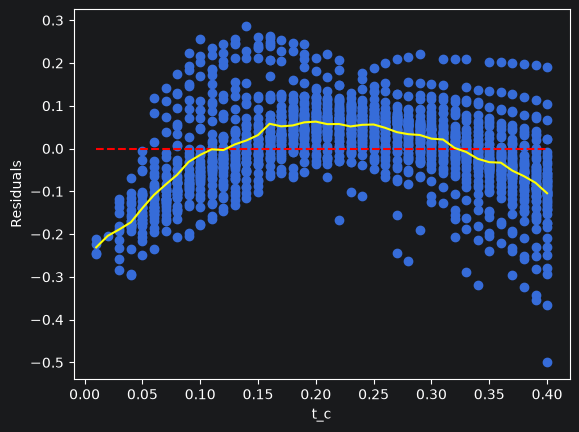

In [166]:
# Plot residuals against individual predictors
plot_residuals(X_train['m'],model,xlabel="m",training_observations=X_train)
plot_residuals(X_train['p'],model,xlabel="p",training_observations=X_train)
plot_residuals(X_train['t_c'],model,xlabel="t_c",training_observations=X_train)

Observations:
- Residuals w.r.t. parameter m are centered around zero, except for the special case of m=0
    - This suggests that linear dependence of CL on m is adequate
    - Residuals however do show changing variance
- Same is true for the residuals w.r.t. the parameter p, where the residuals however show a modest oscillation around the zero line, suggesting more non-linear dependence of CL on p
- Residuals show a strong arch pattern with respect to the thickness parameter, strongly indicating non-linear dependence of CL on thickness

# Adding parameter $t_c^2$

In [167]:
X_train['t_c^2'] = X_train['t_c']**2# Define predictors and response
X = df_model[['m','p','t_c']]
y = df_model['CL']

# Split the data into training and test sets
X_train_quad = X_train.copy()

# Fit the model
model_quad = sm.OLS(y_train,X_train).fit()
print(model_quad.summary())

# Update the list of included parameters
parameters_list.append('t_c^2')

                            OLS Regression Results                            
Dep. Variable:                     CL   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.947
Method:                 Least Squares   F-statistic:                     8392.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:00:25   Log-Likelihood:                 2261.7
No. Observations:                1869   AIC:                            -4513.
Df Residuals:                    1864   BIC:                            -4486.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1949      0.009     22.352      0.0

Observations:
- R2 increased from 0.913 to 0.947
- The overall model remains highly statistically significant (F-value)
- The inclusion of the square of thickness seemed to improve the model as it now explains more of the variability in the data
- The standard errors remain small w.r.t. the value of all coefficients
- Coefficient of t_c is now positive
- Both t_c and t_c^2 have very small p-values, providing strong evidence that thickness has both linear and nonlinear contributions within this model.
- The positive coefficient of t_c and negative coefficient of t_c^2 imply an inverted-parabolic thickness effect, with maximum predicted C_L near t/c~0.088, consistent with the EDA.
- The quadratic thickness term has t=-34.76, corresponding to a partial F-statistic of approximately 1208 because F=t^2 when only one term is added.
This provides very strong evidence that including t_c^2 improves the model relative to the simpler additive linear model.

Note:
p-value of a coefficient says: If this coefficient is zero in reality, how probable would it be to get the estimated coefficient just by chance, relative to its uncertainty?


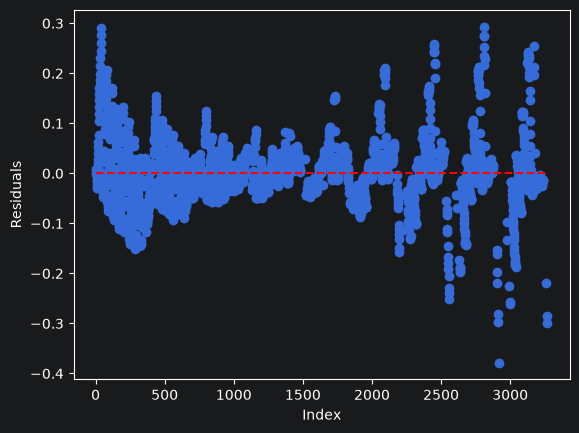

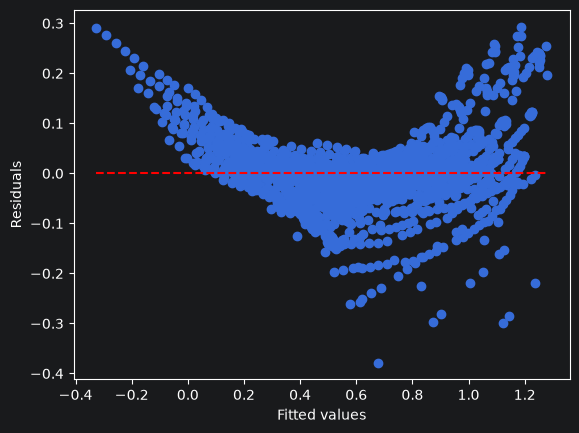

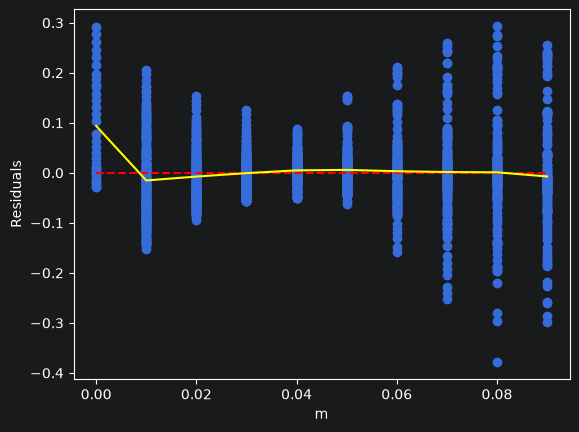

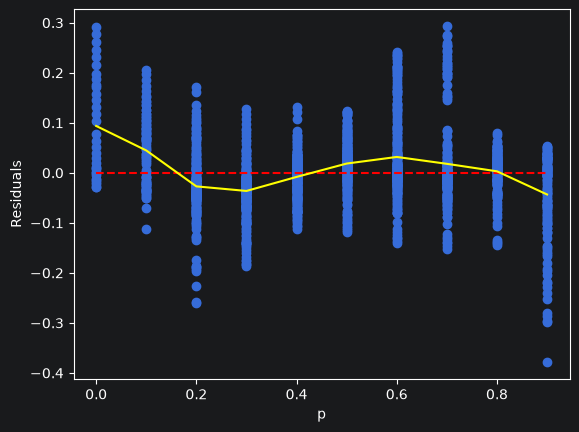

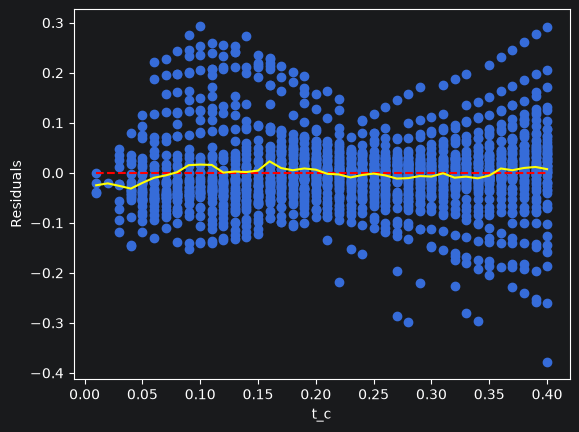

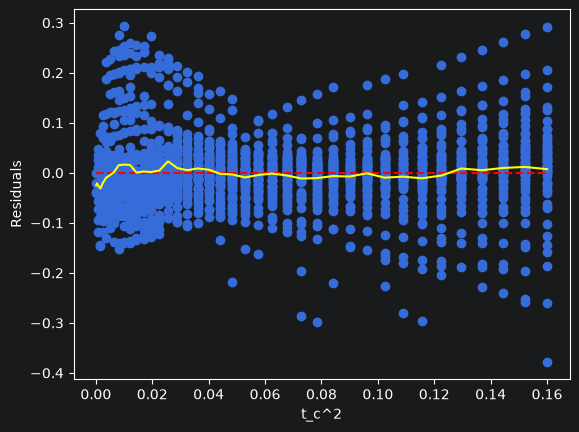

In [168]:
get_residuals_plots(X_train_quad,model_quad,parameters_list)

Observations:
- Clusters of larger residuals are more visible in the index plot, with the residuals spreading more towards higher indexes.
- Residuals against fitted values still show very strong U-pattern, indicating that the model still systematically misfits the data
- No significant change is present in the residual plots for m and p parameters
- Significant improvement is observed in t_c plot, where the residuals are now centered around the zero line
    - The residuals however vary with the value of t_c, indicating a changing error variance a.k.a. heteroscedasticity
- The residuals w.r.t. the t_c^2 show the same characteristics as for t_c

Note:
When a model contains polynomial terms such as \(x^2\) or \(x^3\), it is usually sufficient to inspect residuals against the original physical predictor \(x\). If the transformation is one-to-one over the domain of interest, plotting residuals against \(x^2\) or \(x^3\) mostly just rescales the horizontal axis and does not reveal fundamentally new information.
For interpretation, residuals versus the original predictor are usually preferable. Engineered terms should be plotted separately only when the transformation is not one-to-one or when the transformed feature has a specific diagnostic meaning.
Interaction terms are different: rather than plotting residuals only against the product \(x_1x_2\), it is often more informative to inspect residuals versus one predictor at different levels of the other.

One-to-one transformation: A transformation where two distinct input values cannot produce the same output. Equivalently, the original value can be uniquely recovered from the transformed value. A strictly monotonic transformation is one-to-one over that domain. This depends not only on the operation f(x) but also on the values of x. For example, f(x) = x^2 is one-to-one for x>0, but is not if x can be negative, as e.g. x=-2 and x=2 will produce the same result.

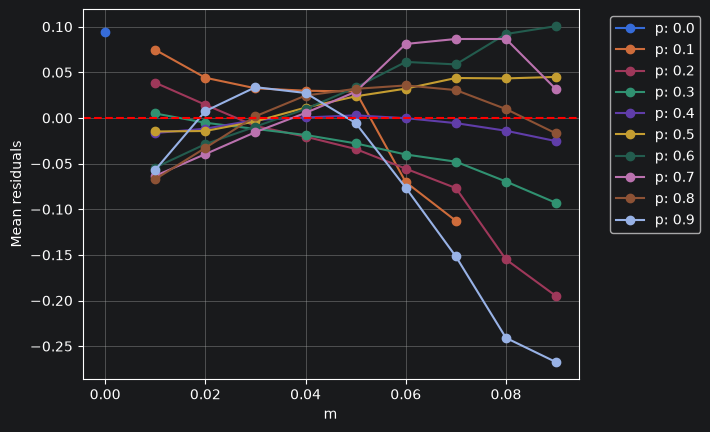

In [169]:
# Plot the residuals w.r.t. the parameter m for different values of p
plot_mean_residuals(X_train_quad,model_quad,'m','p')

Observations:
- The residuals show significantly different behavior w.r.t. the parameter m depending on the value of p
- This indicates that the effect of m on CL is not constant across values of p, providing evidence for interaction effects between m and p

# Adding mp interaction term

In [170]:
X_train_interaction = X_train_quad.copy()
X_train_interaction['mp'] = X_train_interaction['m']*X_train_interaction['p']
model_interaction = sm.OLS(y_train,X_train_interaction).fit()
print(model_interaction.summary())

# Update the list of included parameters
parameters_list.append('mp')

                            OLS Regression Results                            
Dep. Variable:                     CL   R-squared:                       0.954
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     7748.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:00:26   Log-Likelihood:                 2389.5
No. Observations:                1869   AIC:                            -4767.
Df Residuals:                    1863   BIC:                            -4734.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2783      0.010     29.045      0.0

Observations:
- R2 increased from 0.947 to 0.954, so only by 0.7%
- The model remains statistically significant
- Previous observations about the parameters, standard errors and p-values hold
- The new parameter mp is statistically significant
- The interaction term \(mp\) is highly statistically significant. Since only one term was added, its \(t\)-statistic corresponds to a partial \(F\)-statistic of approximately \(273\), providing strong evidence that the interaction improves model fit.
- The positive \(mp\) coefficient means that the effect of \(m\) on \(C_L\) increases with \(p\), and equivalently the effect of \(p\) increases with \(m\).
Main-effect coefficients \(m\) and \(p\) must now be interpreted conditionally because an interaction is present.

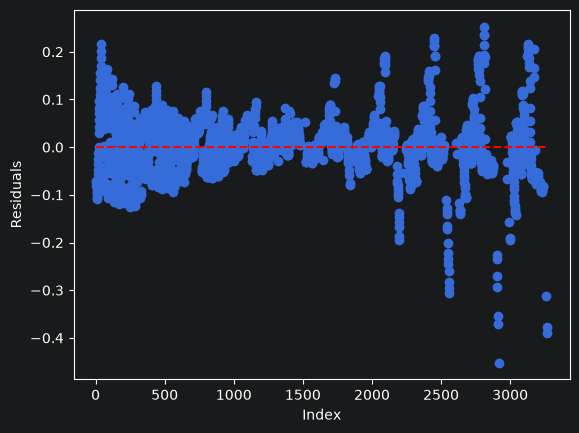

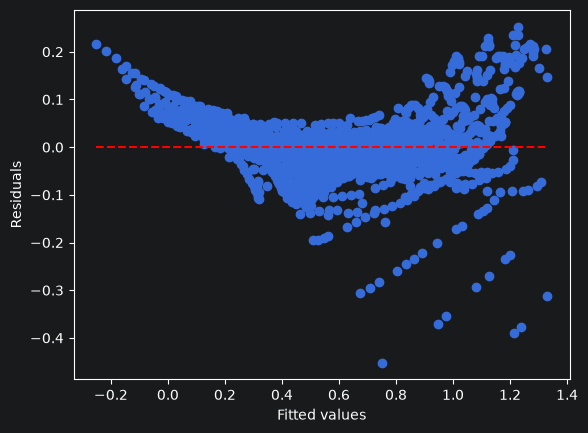

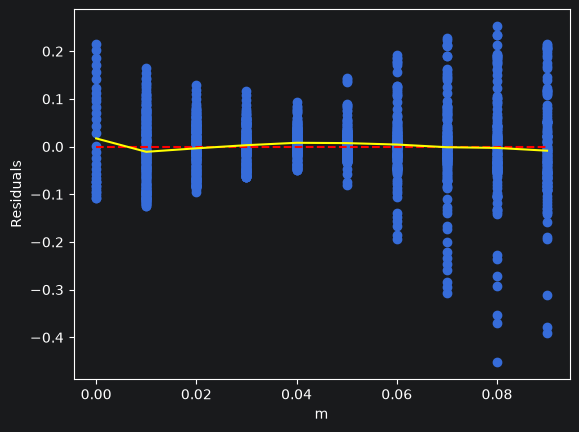

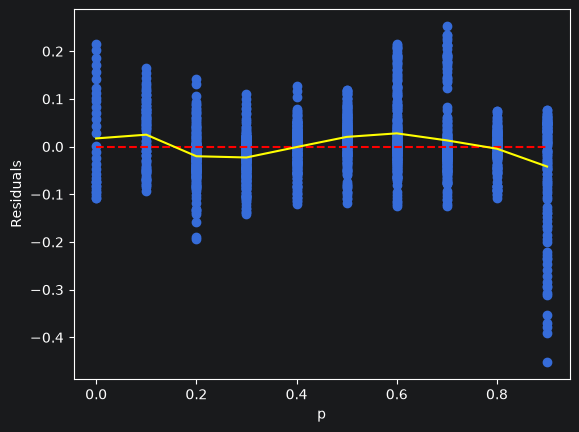

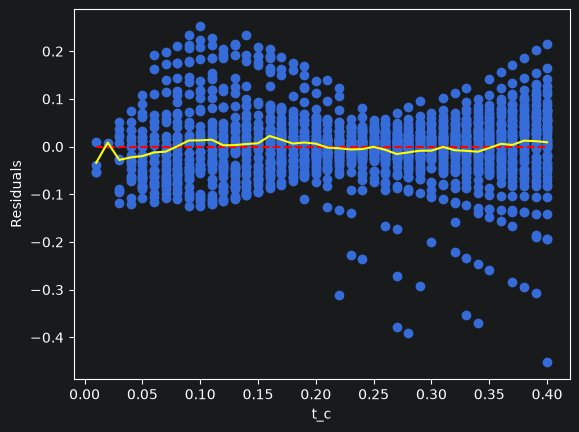

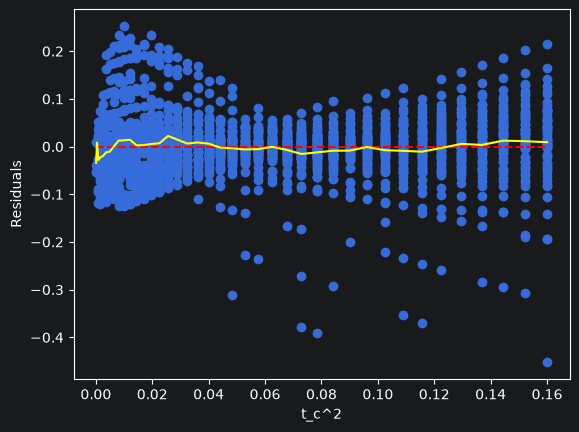

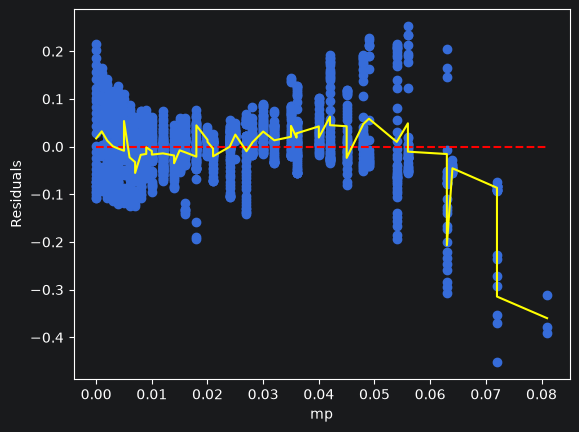

In [171]:
# Plot the residuals
get_residuals_plots(X_train_interaction,model_interaction,parameters_list)

Observations:
- Residual plots w.r.t. m, p, t_c and t_c^2 remained unchanged
- Plot of residuals against the fitted value still shows a strong U-pattern, indicating that the model still does not fully fit the data
- At larger values of \(mp\), the residual distribution becomes increasingly irregular and negatively biased. These values correspond to high-\(m\), high-\(p\) regions where the EDA showed substantial XFOIL convergence losses, so the pattern may partly reflect the changing composition and reduced coverage of the available data.
- The spread of residuals against changes with mp, again indicating heteroscedasticity


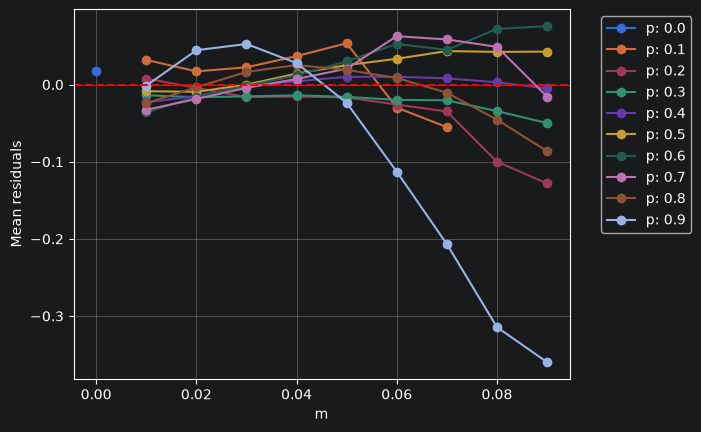

In [172]:
# Plot the residuals w.r.t. the parameter m for different values of p
plot_mean_residuals(X_train_interaction,model_interaction,'m','p')

Observations:
- Introduction of the interaction parameter mp did help to reduce the size of the residuals and to center the residuals around zero, but only at value of m below ~0.06.
- Above m~0.06, the residuals are still large and biased away from zero
- The case of p=0.9 diverges from zero in especially large amount, for mp above 0.6. This could be influenced by convergence issues and the resulting lack of datapoints

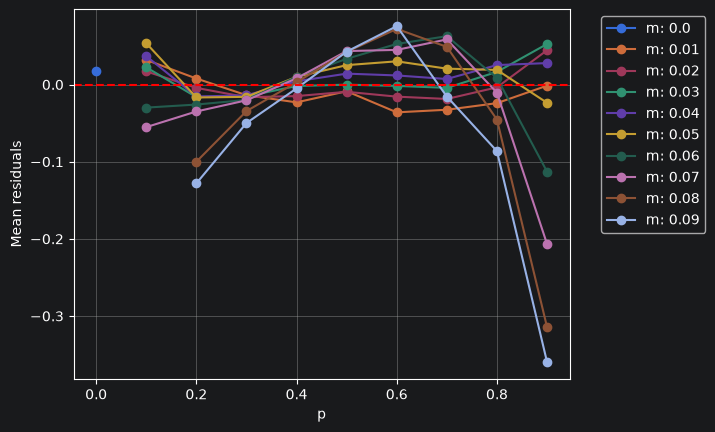

In [173]:
# Plot the residuals w.r.t. the parameter m for different values of p
plot_mean_residuals(X_train_interaction,model_interaction,'p','m')


Observations:
- The mean residual pattern versus \(p\) changes substantially with \(m\), especially at high camber.
- This suggests that the remaining model misspecification is not explained by a common nonlinear effect of \(p\) alone, but instead involves additional interaction structure between \(m\) and \(p\).
- If the misspecification was due to non-linear p effects, the shape would not change with m and a stronger pattern would be visible in plot of residuals w.r.t. p

Note:
- The logical next step would be to add parameter mp^2, given the observations above and the fact that EDA indicated linear dependence of CL on m
- However, hierarchy principle states that if mp^2 is to be included, the model should also contain m and p^2 individually as well
- So p^2 will be added next

# Including parameter $p^2$

In [174]:
# Fit a model with the parameter p^2 included
X_train_p2 = X_train_interaction.copy()
X_train_p2['p^2'] = X_train_p2['p']*X_train_p2['p']
model_p2 = sm.OLS(y_train,X_train_p2).fit()
print(model_p2.summary())

# Update the list of included parameters
parameters_list.append('p^2')

                            OLS Regression Results                            
Dep. Variable:                     CL   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.955
Method:                 Least Squares   F-statistic:                     6600.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:00:27   Log-Likelihood:                 2409.6
No. Observations:                1869   AIC:                            -4805.
Df Residuals:                    1862   BIC:                            -4767.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2539      0.010     24.807      0.0

Observations:
- R2 Remains virtually unchanged, so p^2 provides only a modest improvement in overall model fit.
- Previous observations hold
- The \(p^2\) coefficient is nevertheless highly statistically significant (\(t=-6.36\), \(p\approx0\)); equivalently, the partial \(F\)-statistic for adding \(p^2\) is about 40.4.
- Therefore, there is strong evidence for some nonlinear dependence on \(p\), although its contribution to explained variance is relatively small.

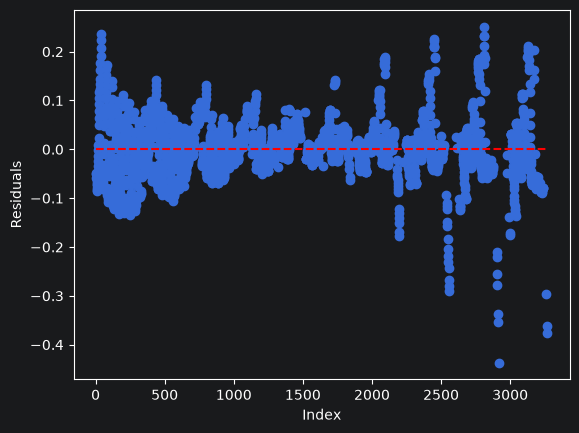

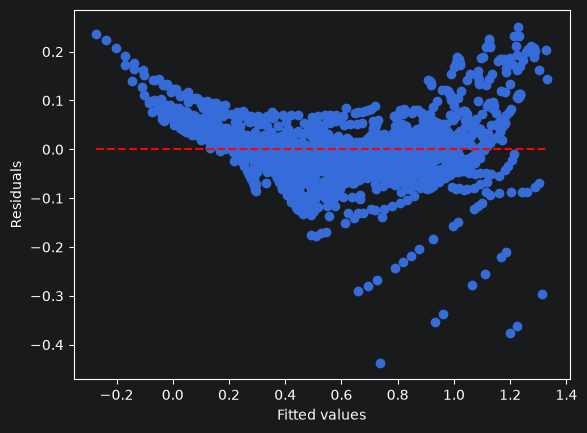

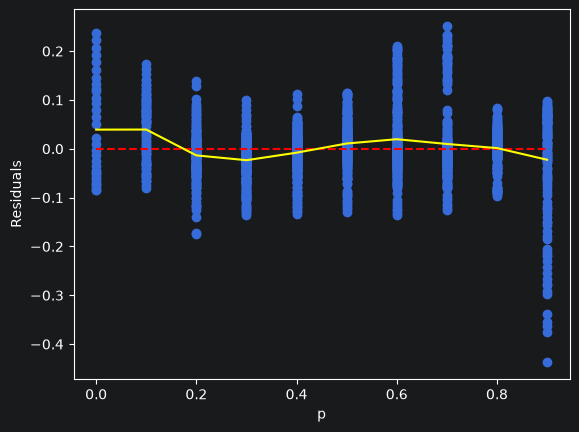

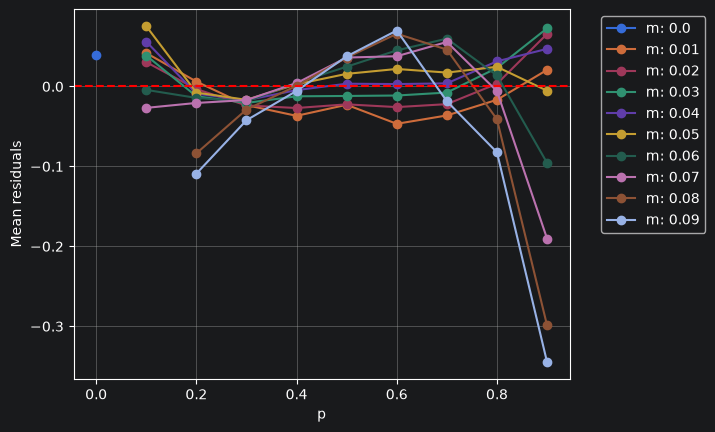

In [175]:
get_residuals_plots(X_train_p2,model_p2,['p'])
plot_mean_residuals(X_train_p2,model_p2,'p','m')

Observations:
- The inclusion of \(p^2\) produced only a negligible improvement in the residual structure and overall fit, despite the \(p^2\) coefficient being statistically significant.

# Including parameter $mp^2$

In [180]:
X_train_mp2 = X_train_p2.copy()
X_train_mp2['mp^2'] = X_train_mp2['m']*X_train_mp2['p']*X_train_mp2['p']
model_mp2 = sm.OLS(y_train,X_train_mp2).fit()
print(model_mp2.summary())

parameters_list.append('mp^2')

                            OLS Regression Results                            
Dep. Variable:                     CL   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.963
Method:                 Least Squares   F-statistic:                     7040.
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        13:00:37   Log-Likelihood:                 2606.1
No. Observations:                1869   AIC:                            -5196.
Df Residuals:                    1861   BIC:                            -5152.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3505      0.010     33.986      0.0

Observations:
- \(R^2\) increased from about 0.955 to 0.964, an increase of 0.9 percentage points. This corresponds to roughly a 20% reduction in the remaining unexplained variance.
- The \(mp^2\) term is highly statistically significant (t=-20.87, p~0); equivalently, its partial F-statistic is about 435.
- The strong improvement supports the hypothesis that the m-p interaction is nonlinear in p.
- Several lower-order coefficients changed substantially after adding mp^2, so they should be interpreted jointly within the hierarchical interaction model rather than compared in isolation with their previous values.

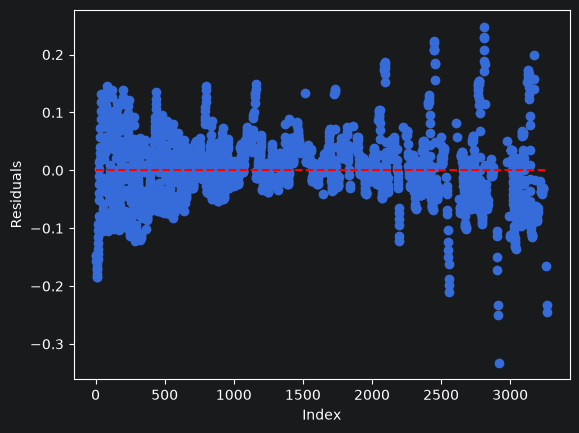

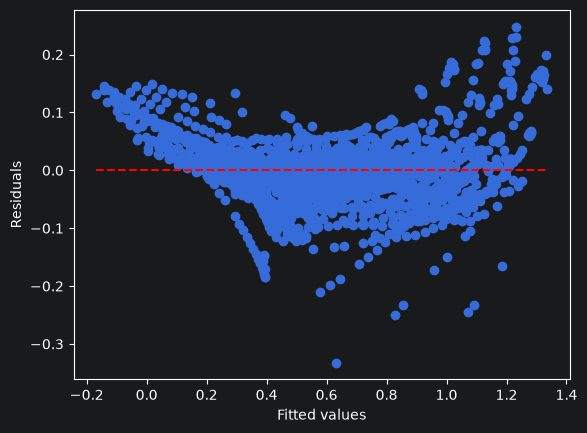

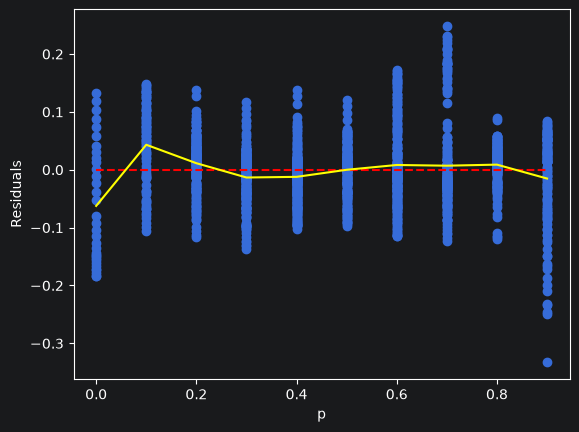

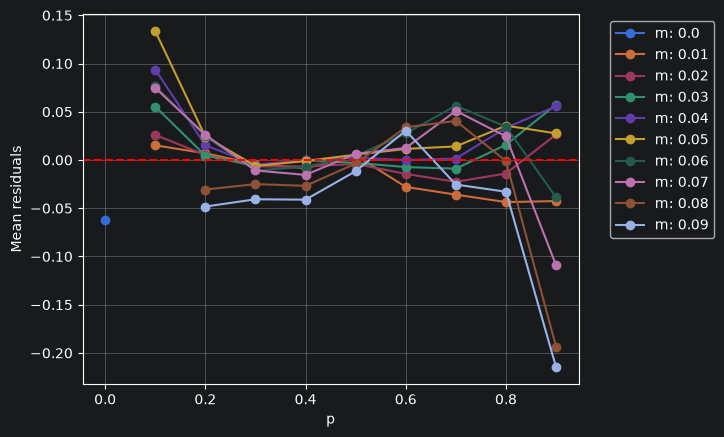

In [181]:
get_residuals_plots(X_train_mp2,model_mp2,['p'])
plot_mean_residuals(X_train_mp2,model_mp2,'p','m')

Observations:
- The mp^2 factor did reduce some interaction related residual structure but the U-pattern in the plot against fitted values still remains and bias still remains in the residual plot w.r.t. p
- This factor therefore did not resolve the main issues observed in previous iteration of the model and differnt additional factors need to be investigated

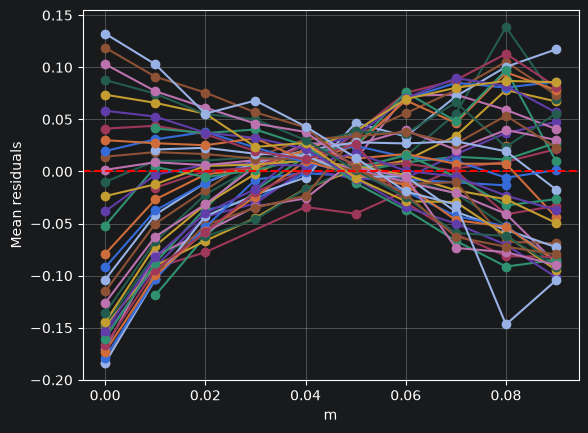

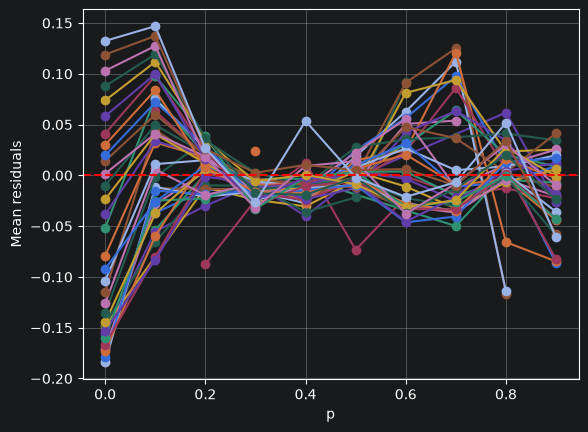

In [195]:
# Investigate the next possible interactions
plot_mean_residuals(X_train_mp2,model_mp2,'m','t_c',legend=False)
plot_mean_residuals(X_train_mp2,model_mp2,'p','t_c',legend=False)

Observations:
- The mean residual pattern versus m changes substantially across different values of t_c, indicating that the effect of m on CL depends on thickness. This suggests an m*t_c interaction.
- The mean residual pattern versus p also changes across different values of t_c, indicating that the effect of p on CL depends on thickness. This suggests a p*t_c interaction.

# Adding parameter $m t_c$

## NOTE: Since the parameter $mp^2$ did not improve the model, both $mp^2$ and $p^2$ will be removed before adding $m t_c$

In [221]:
# Remove the mp^2 and p^2 parameters
parameters_list = ['m', 'p', 't_c', 't_c^2', 'mp']

X_train_mtc = X_train_interaction.copy()
X_train_mtc["mt_c"] = X_train_mtc["m"]*X_train_mtc["t_c"]
model_mtc = sm.OLS(y_train,X_train_mtc).fit()
print(model_mtc.summary())


                            OLS Regression Results                            
Dep. Variable:                     CL   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.975
Method:                 Least Squares   F-statistic:                 1.231e+04
Date:                Fri, 02 Oct 2026   Prob (F-statistic):               0.00
Time:                        14:55:18   Log-Likelihood:                 2972.2
No. Observations:                1869   AIC:                            -5930.
Df Residuals:                    1862   BIC:                            -5892.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1067      0.008     12.981      0.0

Observations:
- R^2 increased from approximately 0.954 to 0.975, corresponding to an increase of about 2.1 percentage points in explained variance.
- The unexplained variance decreased from about 4.6% to 2.5%, a reduction of roughly 46%.
- The m*t_c interaction is highly statistically significant, with t ≈ -40.1. Since only one term was added, the equivalent partial F-statistic is approximately 1612.
- This provides strong evidence that the effect of m on CL depends on thickness, consistent with the grouped residual diagnostics.

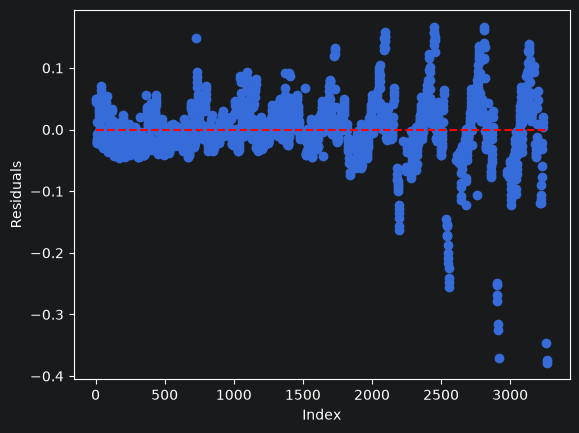

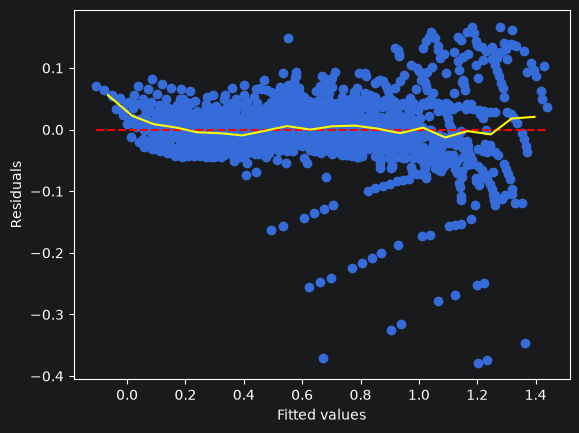

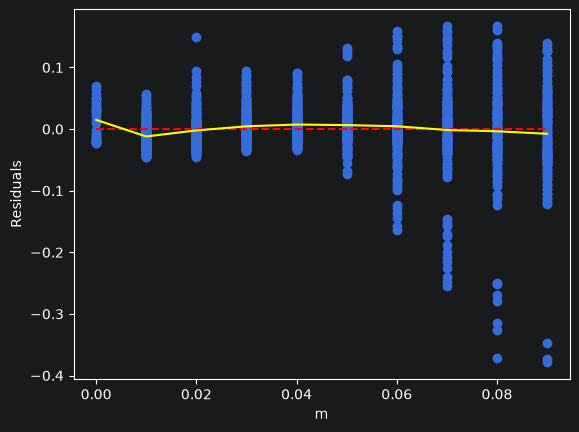

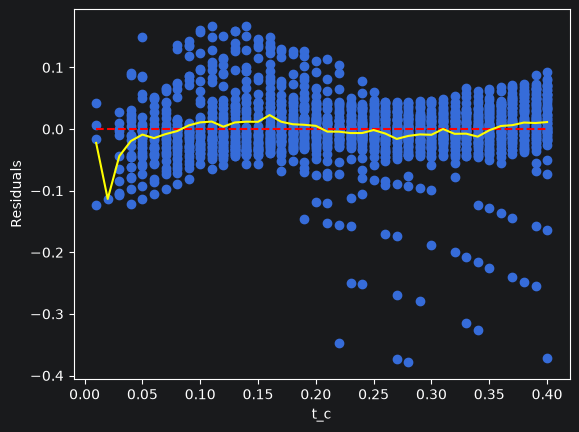

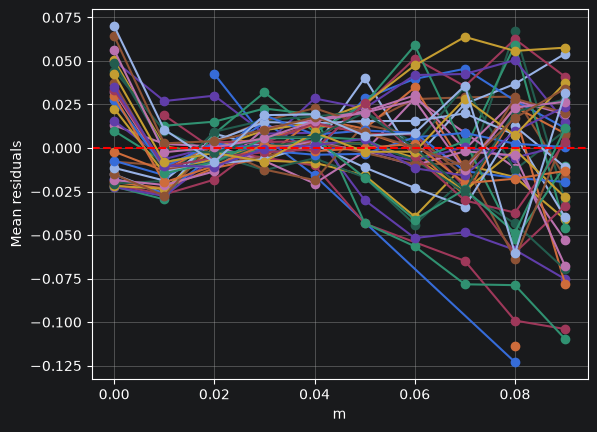

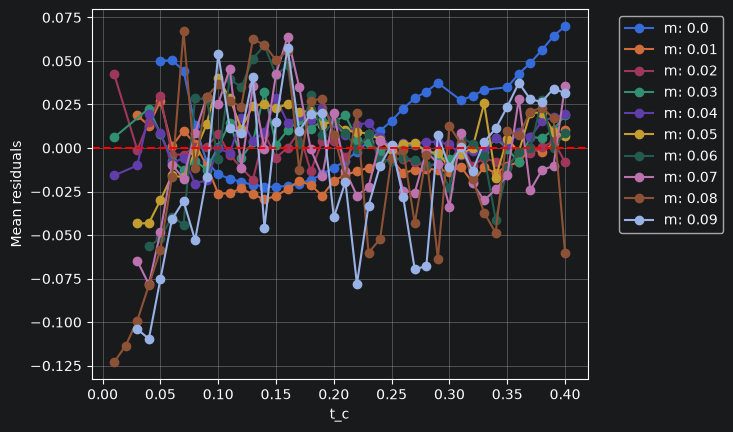

In [222]:
get_residuals_plots(X_train_mtc,model_mtc,['m','t_c'])
plot_mean_residuals(X_train_mtc,model_mtc,'m','t_c',legend=False)
plot_mean_residuals(X_train_mtc,model_mtc,'t_c','m',legend=True)

Observations:
- Adding the m*t_c interaction greatly improved the residual behavior. The strong systematic curvature previously visible in the residual-vs-fitted plot has largely disappeared.
- The mean residuals versus both m and t_c remain close to zero across most of their ranges, suggesting that the model now captures their mean relationship with CL much better.
- The residual spread still changes substantially across m, t_c, and fitted values, indicating that non-constant residual variance remains.
- Several relatively large negative residuals remain, particularly in parts of the high-m / high-t_c region, so some local model misspecification or data-coverage effects may still be present.
- Adding m*t_c substantially improved the residual-vs-fitted behavior and reduced the mean residual structure.
- Grouped residual plots still show that the effect of m varies with t_c, and the effect of t_c varies with m.
    - This indicates that the m*t_c interaction is important but not fully captured by a simple linear interaction term.
- The remaining structure suggests possible higher-order interaction effects